# <font color="brown">Regularization Case Study </font>

## <font color = "brown">Problem Statement </font>
Build a model to predict the price of a house based on the data shared, and study how Ridge and Lasso regularization change the model compared to a plain Linear Regression.

## <font color = "brown">Data Dictionary </font>
* price: Price of house
* area: Area of house
* bedrooms: Number of bedrooms
* bathrooms: Number of bathrooms
* stories: Number of floors
* mainroad: Is the property situated on the main road?
* guestroom: Does the house have guest room?
* basement: Does the house have basement?
* hotwaterheating: Does the house have hot water heating?
* airconditioning: Does the house have air conditioning?
* parking: Number of parking available
* prefarea: Is the property in the preffered area?
* furnishingstatus: Type of furnishing of the house

### <font color="blue"> Importing the libraries required

In [392]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error

%matplotlib inline

### <font color="blue"> Reading file and understanding the data

In [394]:
data = pd.read_csv("Housing.csv")

In [395]:
#Creating a copy of the data
df = data.copy()

**Let us check the shape of the data**

In [397]:
df.shape

(545, 13)

The data has 545 observations and 13 features.

**Checking the data types**

In [400]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


6 columns are numeric and 7 columns are categorical (object type).

### <font color="blue"> Missing Value Check

In [403]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

There are no missing values in the data.

### <font color="blue"> Checking Duplicates

In [406]:
df.duplicated().sum()

0

There are no duplicate rows in the data.

## <font color="brown"> Why Regularization?

A plain Linear Regression model can end up relying too heavily on a few features, especially when some of the features are correlated with each other (multicollinearity), and this can hurt how well the model generalises to new data. **Regularization** fixes this by adding a penalty on the size of the coefficients, so the model is discouraged from assigning very large weights to any one feature.

* **Ridge Regression** adds a penalty on the *sum of squared coefficients* (L2 penalty). It shrinks coefficients smoothly towards zero, but never exactly to zero.
* **Lasso Regression** adds a penalty on the *sum of absolute coefficients* (L1 penalty). It can shrink some coefficients exactly to zero, effectively performing feature selection.

Let's first check how correlated our numeric features are, since that is exactly the kind of situation regularization helps with.

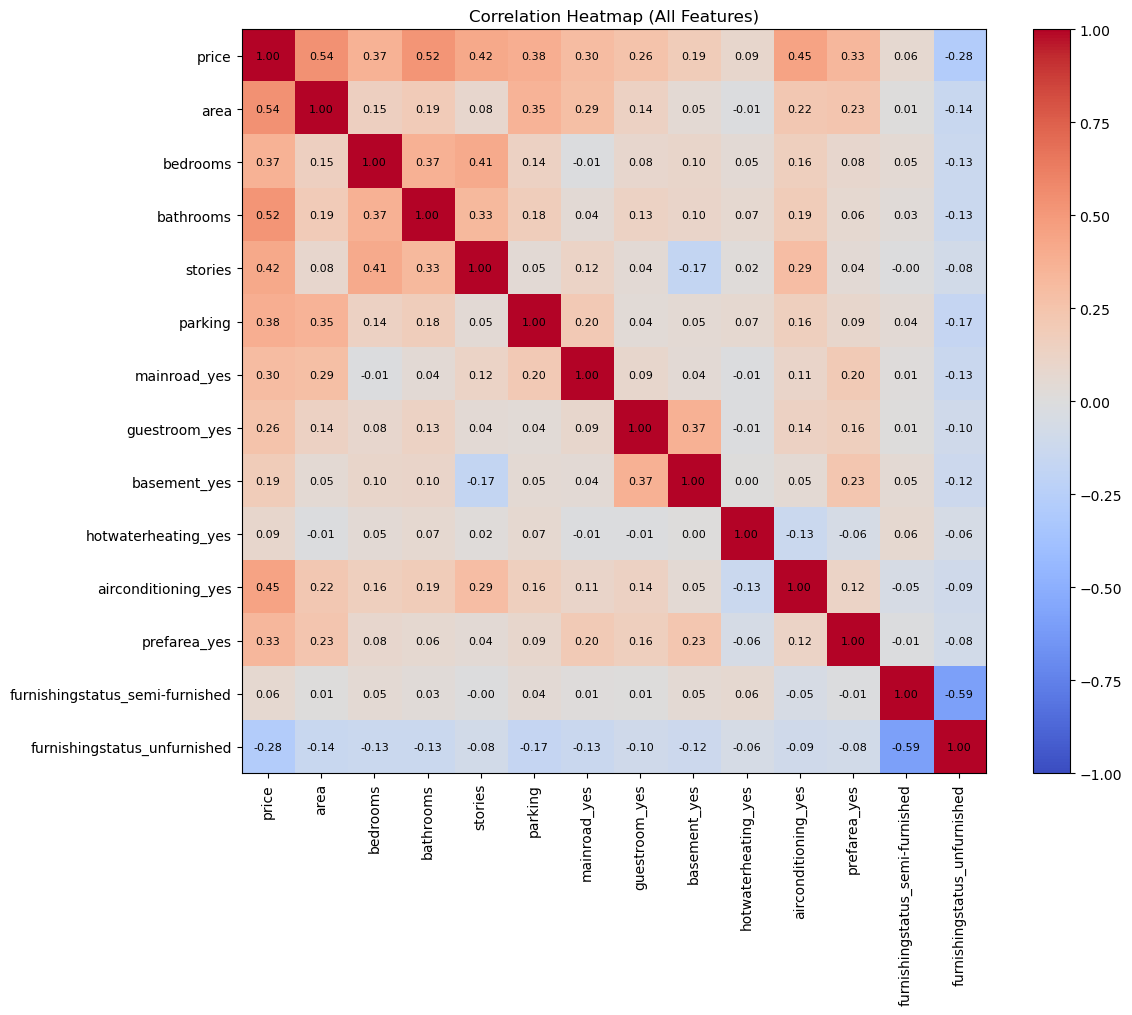

In [409]:
df_corr = pd.get_dummies(
    df,
    columns=df.select_dtypes(include='object').columns.to_list(),
    drop_first=True,
    dtype=int,
)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

# Annotating each cell manually with its correlation value
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap (All Features)')
plt.tight_layout()
plt.show()

A few things stand out once we look at every feature, not just its correlation with `price`:

* `area`, `bathrooms`, `stories`, `airconditioning_yes`, and `parking` all have a moderate positive correlation with `price` (0.35–0.55).
* `bathrooms` and `bedrooms` are moderately correlated with each other (0.37), and so are `basement_yes` and `guestroom_yes` (0.37), houses with one tend to have the other.
* `furnishingstatus_semi-furnished` and `furnishingstatus_unfurnished` are correlated with each other (-0.59) simply because they come from the same one-hot encoded column.

None of these are extreme (nothing above ~0.6), but there's enough overlap between features, especially once we bring in the dummy variables, that regularization is a sensible precaution against the model over-relying on any single one of them.

## <font color="brown"> Data Preparation

Just like in the Linear Regression case study, log-transforming the target variable makes the price distribution better behaved for modeling.

In [413]:
df['log_price'] = np.log(df['price'])

Splitting the data into independent and dependent variables.

In [415]:
X = df.drop(['price', 'log_price'], axis=1)
y = df['log_price']

Creating the dummy variables for the categorical columns.

In [417]:
X = pd.get_dummies(
    data=X,
    columns=X.select_dtypes(include='object').columns.to_list(),
    drop_first=True,
    dtype=int,
)

X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


Splitting the data into train and test. 70% of the data goes to train and 30% goes to test.

In [419]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### <font color="blue"> Feature Scaling

Ridge and Lasso penalize coefficients based on their size, so if features are left on very different scales (e.g. `area` in thousands vs a 0/1 dummy column), the penalty would unfairly shrink the large-scale features more than the others. We use `StandardScaler` to bring every feature to the same scale, fitting it only on the training data to avoid leaking information from the test set.

In [ ]:
#(x - mean())/std() - Standard Scaler

In [421]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
180,-0.326835,1.323414,1.398729,-0.928204,1.520466,-2.434599,-0.453537,1.342189,-0.222681,1.540026,-0.572299,1.15647,-0.673942
189,-0.754726,-1.302736,-0.582370,-0.928204,-0.796724,-2.434599,2.204890,1.342189,-0.222681,-0.649340,-0.572299,1.15647,-0.673942
93,0.876611,0.010339,1.398729,-0.928204,2.679062,0.410745,-0.453537,1.342189,-0.222681,1.540026,-0.572299,1.15647,-0.673942
444,-0.941929,0.010339,-0.582370,0.254558,-0.796724,-2.434599,-0.453537,-0.745052,-0.222681,-0.649340,-0.572299,-0.86470,-0.673942
81,-0.549695,0.010339,1.398729,0.254558,0.361871,0.410745,-0.453537,1.342189,-0.222681,1.540026,-0.572299,1.15647,-0.673942


All features are now on the same scale, so we can build our models fairly.

## <font color="brown"> Model 1: Linear Regression (Baseline)

Building a plain Linear Regression model, with no regularization, as our baseline.

In [425]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.11, 0.01, 0.09,..., 0.05, 0. ,-0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.31
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


Building the linear regression formula. Since we log-transformed the target, this formula predicts `log_price`, take `exp()` of the result to get the predicted price in rupees.

In [427]:
intercept = lr_model.intercept_
coefficients = lr_model.coef_
feature_names = X_train_scaled.columns

formula = f"log_price = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    formula += f" + ({coef:.4f} * {name})"

print(formula)

log_price = 15.3127 + (0.1077 * area) + (0.0124 * bedrooms) + (0.0910 * bathrooms) + (0.0888 * stories) + (0.0398 * parking) + (0.0486 * mainroad_yes) + (0.0246 * guestroom_yes) + (0.0624 * basement_yes) + (0.0318 * hotwaterheating_yes) + (0.0575 * airconditioning_yes) + (0.0456 * prefarea_yes) + (0.0039 * furnishingstatus_semi-furnished) + (-0.0505 * furnishingstatus_unfurnished)


Predicting on the train and test set using the model created.

In [429]:
train_pred_lr = lr_model.predict(X_train_scaled)
test_pred_lr = lr_model.predict(X_test_scaled)

### <font color="blue"> Model 1 Metrics

In [431]:
train_r2_lr = r2_score(y_true=y_train, y_pred=train_pred_lr)
test_r2_lr = r2_score(y_true=y_test, y_pred=test_pred_lr)

train_rmse_lr = root_mean_squared_error(y_true=y_train, y_pred=train_pred_lr)
test_rmse_lr = root_mean_squared_error(y_true=y_test, y_pred=test_pred_lr)

print("Train R2:", train_r2_lr, " Test R2:", test_r2_lr)
print("Train RMSE:", train_rmse_lr, " Test RMSE:", test_rmse_lr)

Train R2: 0.7036861890139566  Test R2: 0.6690328794181711
Train RMSE: 0.19754491022596332  Test RMSE: 0.22519768052107114


**The baseline model gets an R2 of ~0.70 on train and ~0.67 on test, so it isn't badly overfitting to begin with. Let's see whether Ridge and Lasso can still improve on this.**

## <font color="brown"> Model 2: Ridge Regression (Default alpha)

Building a Ridge Regression model with the default `alpha=1.0`.

In [435]:
ridge_default = Ridge(alpha=1.0)
ridge_default.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

Building the Ridge (default alpha) formula.

In [437]:
intercept = ridge_default.intercept_
coefficients = ridge_default.coef_
feature_names = X_train_scaled.columns

formula = f"log_price = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    formula += f" + ({coef:.4f} * {name})"

print(formula)

log_price = 15.3127 + (0.1074 * area) + (0.0126 * bedrooms) + (0.0908 * bathrooms) + (0.0885 * stories) + (0.0399 * parking) + (0.0486 * mainroad_yes) + (0.0247 * guestroom_yes) + (0.0622 * basement_yes) + (0.0317 * hotwaterheating_yes) + (0.0574 * airconditioning_yes) + (0.0456 * prefarea_yes) + (0.0039 * furnishingstatus_semi-furnished) + (-0.0504 * furnishingstatus_unfurnished)


In [438]:
train_pred_ridge_d = ridge_default.predict(X_train_scaled)
test_pred_ridge_d = ridge_default.predict(X_test_scaled)

### <font color="blue"> Model 2 Metrics

In [440]:
train_r2_ridge_d = r2_score(y_true=y_train, y_pred=train_pred_ridge_d)
test_r2_ridge_d = r2_score(y_true=y_test, y_pred=test_pred_ridge_d)

train_rmse_ridge_d = root_mean_squared_error(y_true=y_train, y_pred=train_pred_ridge_d)
test_rmse_ridge_d = root_mean_squared_error(y_true=y_test, y_pred=test_pred_ridge_d)

print("Train R2:", train_r2_ridge_d, " Test R2:", test_r2_ridge_d)
print("Train RMSE:", train_rmse_ridge_d, " Test RMSE:", test_rmse_ridge_d)

Train R2: 0.7036844949022352  Test R2: 0.6691549642881753
Train RMSE: 0.19754547493583707  Test RMSE: 0.22515614200608314


**The default Ridge model performs almost identically to the baseline. `alpha=1.0` is a fairly mild penalty here, so it barely changes anything, this is exactly why we need to tune `alpha` instead of just using the default.**

## <font color="brown"> Model 3: Ridge Regression (Tuned)

Using `GridSearchCV` to search over a range of `alpha` values and find the one that generalises best.

In [444]:
ridge_alphas = np.logspace(-3, 2, 50)

ridge_grid = GridSearchCV(Ridge(), {'alpha': ridge_alphas}, scoring='r2', cv=5)
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha for Ridge:", ridge_grid.best_params_["alpha"])

Best alpha for Ridge: 9.540954763499943


Building the final Ridge model using the best alpha found.

In [446]:
ridge_tuned = ridge_grid.best_estimator_
ridge_tuned.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",9.540954763499943
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 's

Building the Ridge (tuned) formula.

In [448]:
intercept = ridge_tuned.intercept_
coefficients = ridge_tuned.coef_
feature_names = X_train_scaled.columns

formula = f"log_price = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    formula += f" + ({coef:.4f} * {name})"

print(formula)

log_price = 15.3127 + (0.1051 * area) + (0.0142 * bedrooms) + (0.0897 * bathrooms) + (0.0862 * stories) + (0.0400 * parking) + (0.0487 * mainroad_yes) + (0.0254 * guestroom_yes) + (0.0603 * basement_yes) + (0.0309 * hotwaterheating_yes) + (0.0571 * airconditioning_yes) + (0.0455 * prefarea_yes) + (0.0043 * furnishingstatus_semi-furnished) + (-0.0497 * furnishingstatus_unfurnished)


In [449]:
train_pred_ridge_t = ridge_tuned.predict(X_train_scaled)
test_pred_ridge_t = ridge_tuned.predict(X_test_scaled)

### <font color="blue"> Model 3 Metrics

In [451]:
train_r2_ridge_t = r2_score(y_true=y_train, y_pred=train_pred_ridge_t)
test_r2_ridge_t = r2_score(y_true=y_test, y_pred=test_pred_ridge_t)

train_rmse_ridge_t = root_mean_squared_error(y_true=y_train, y_pred=train_pred_ridge_t)
test_rmse_ridge_t = root_mean_squared_error(y_true=y_test, y_pred=test_pred_ridge_t)

print("Train R2:", train_r2_ridge_t, " Test R2:", test_r2_ridge_t)
print("Train RMSE:", train_rmse_ridge_t, " Test RMSE:", test_rmse_ridge_t)

Train R2: 0.7035406088062419  Test R2: 0.6699886391773695
Train RMSE: 0.19759343158500314  Test RMSE: 0.2248722849153598


**With a much larger, tuned alpha (~9.5), Ridge gives a small but genuine improvement in test R2/RMSE over both the baseline and the default Ridge model, while train performance drops very slightly. That's regularization doing its job: trading a bit of train fit for better generalisation.**

## <font color="brown"> Model 4: Lasso Regression (Default alpha)

Building a Lasso Regression model with the default `alpha=1.0`.

In [455]:
lasso_default = Lasso(alpha=1.0)
lasso_default.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


Building the Lasso (default alpha) formula.

In [457]:
intercept = lasso_default.intercept_
coefficients = lasso_default.coef_
feature_names = X_train_scaled.columns

formula = f"log_price = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    formula += f" + ({coef:.4f} * {name})"

print(formula)

log_price = 15.3127 + (0.0000 * area) + (0.0000 * bedrooms) + (0.0000 * bathrooms) + (0.0000 * stories) + (0.0000 * parking) + (0.0000 * mainroad_yes) + (0.0000 * guestroom_yes) + (0.0000 * basement_yes) + (0.0000 * hotwaterheating_yes) + (0.0000 * airconditioning_yes) + (0.0000 * prefarea_yes) + (0.0000 * furnishingstatus_semi-furnished) + (0.0000 * furnishingstatus_unfurnished)


Every single coefficient is exactly `0.0000`, so the formula collapses to just the intercept, the model predicts the same `log_price` for every house, no matter what its features are.

In [459]:
train_pred_lasso_d = lasso_default.predict(X_train_scaled)
test_pred_lasso_d = lasso_default.predict(X_test_scaled)

### <font color="blue"> Model 4 Metrics

In [461]:
train_r2_lasso_d = r2_score(y_true=y_train, y_pred=train_pred_lasso_d)
test_r2_lasso_d = r2_score(y_true=y_test, y_pred=test_pred_lasso_d)

train_rmse_lasso_d = root_mean_squared_error(y_true=y_train, y_pred=train_pred_lasso_d)
test_rmse_lasso_d = root_mean_squared_error(y_true=y_test, y_pred=test_pred_lasso_d)

print("Train R2:", train_r2_lasso_d, " Test R2:", test_r2_lasso_d)
print("Train RMSE:", train_rmse_lasso_d, " Test RMSE:", test_rmse_lasso_d)

print("Number of non-zero coefficients:", np.sum(lasso_default.coef_ != 0), "out of", len(lasso_default.coef_))

Train R2: 0.0  Test R2: -0.002338442969485044
Train RMSE: 0.36290244770276575  Test RMSE: 0.3919030838593487
Number of non-zero coefficients: 0 out of 13


**The default Lasso model completely collapses, R2 of 0 on both train and test, and every single coefficient has been shrunk to exactly zero! Because our features are scaled and the target is log-transformed, the true coefficients here are quite small to begin with, so `alpha=1.0` turns out to be a massive penalty that wipes out the entire model. This is a strong illustration of why tuning `alpha` isn't optional for Lasso, too much regularization can destroy the model completely.**

## <font color="brown"> Model 5: Lasso Regression (Tuned)

Using `GridSearchCV` again, this time to find a sensible `alpha` for Lasso.

In [465]:
lasso_alphas = np.logspace(-4, 1, 50)

lasso_grid = GridSearchCV(Lasso(max_iter=10000), {'alpha': lasso_alphas}, scoring='r2', cv=5)
lasso_grid.fit(X_train_scaled, y_train)

print("Best alpha for Lasso:", lasso_grid.best_params_["alpha"])

Best alpha for Lasso: 0.0013257113655901094


Building the final Lasso model using the best alpha found.

In [467]:
lasso_tuned = lasso_grid.best_estimator_
lasso_tuned.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.0013257113655901094
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


Building the Lasso (tuned) formula.

In [469]:
intercept = lasso_tuned.intercept_
coefficients = lasso_tuned.coef_
feature_names = X_train_scaled.columns

formula = f"log_price = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    formula += f" + ({coef:.4f} * {name})"

print(formula)

log_price = 15.3127 + (0.1072 * area) + (0.0121 * bedrooms) + (0.0907 * bathrooms) + (0.0880 * stories) + (0.0393 * parking) + (0.0480 * mainroad_yes) + (0.0240 * guestroom_yes) + (0.0616 * basement_yes) + (0.0304 * hotwaterheating_yes) + (0.0567 * airconditioning_yes) + (0.0449 * prefarea_yes) + (0.0027 * furnishingstatus_semi-furnished) + (-0.0506 * furnishingstatus_unfurnished)


In [470]:
train_pred_lasso_t = lasso_tuned.predict(X_train_scaled)
test_pred_lasso_t = lasso_tuned.predict(X_test_scaled)

### <font color="blue"> Model 5 Metrics

In [472]:
train_r2_lasso_t = r2_score(y_true=y_train, y_pred=train_pred_lasso_t)
test_r2_lasso_t = r2_score(y_true=y_test, y_pred=test_pred_lasso_t)

train_rmse_lasso_t = root_mean_squared_error(y_true=y_train, y_pred=train_pred_lasso_t)
test_rmse_lasso_t = root_mean_squared_error(y_true=y_test, y_pred=test_pred_lasso_t)

print("Train R2:", train_r2_lasso_t, " Test R2:", test_r2_lasso_t)
print("Train RMSE:", train_rmse_lasso_t, " Test RMSE:", test_rmse_lasso_t)

print("Number of non-zero coefficients:", np.sum(lasso_tuned.coef_ != 0), "out of", len(lasso_tuned.coef_))

Train R2: 0.7036000143628419  Test R2: 0.668571459301236
Train RMSE: 0.19757363336604958  Test RMSE: 0.22535460630292903
Number of non-zero coefficients: 13 out of 13


**With a much smaller, tuned alpha, Lasso recovers fully and performs on par with the baseline and tuned Ridge model, and keeps all 13 features. On this particular dataset there isn't enough overfitting for Lasso to need to drop any features to get the best test R2, but as we'll see in the regularization path below, it is very much capable of doing so as alpha increases.**

## <font color="brown"> Model Performance Comparison

In [475]:
comparison_df = pd.DataFrame({
    'Model': [
        'Model-1: Linear Regression',
        'Model-2: Ridge (Default alpha)',
        'Model-3: Ridge (Tuned)',
        'Model-4: Lasso (Default alpha)',
        'Model-5: Lasso (Tuned)',
    ],
    'Train R2': [train_r2_lr, train_r2_ridge_d, train_r2_ridge_t, train_r2_lasso_d, train_r2_lasso_t],
    'Test R2': [test_r2_lr, test_r2_ridge_d, test_r2_ridge_t, test_r2_lasso_d, test_r2_lasso_t],
    'Train RMSE': [train_rmse_lr, train_rmse_ridge_d, train_rmse_ridge_t, train_rmse_lasso_d, train_rmse_lasso_t],
    'Test RMSE': [test_rmse_lr, test_rmse_ridge_d, test_rmse_ridge_t, test_rmse_lasso_d, test_rmse_lasso_t],
})
comparison_df

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Model-1: Linear Regression,0.703686,0.669033,0.197545,0.225198
1,Model-2: Ridge (Default alpha),0.703684,0.669155,0.197545,0.225156
2,Model-3: Ridge (Tuned),0.703541,0.669989,0.197593,0.224872
3,Model-4: Lasso (Default alpha),0.000000,-0.002338,0.362902,0.391903
4,Model-5: Lasso (Tuned),0.703600,0.668571,0.197574,0.225355


The tuned Ridge model gives the best test R2/RMSE of the five, the tuned Lasso and baseline Linear Regression are close behind, and the two default-alpha models show just how much the choice of alpha matters, default Ridge barely moves from the baseline, while default Lasso collapses entirely.

## <font color="brown"> Importance of Regularization

### <font color="blue"> Coefficient Comparison

Let's compare the actual coefficient values across the Linear, tuned Ridge, and tuned Lasso models to see how regularization has changed them.

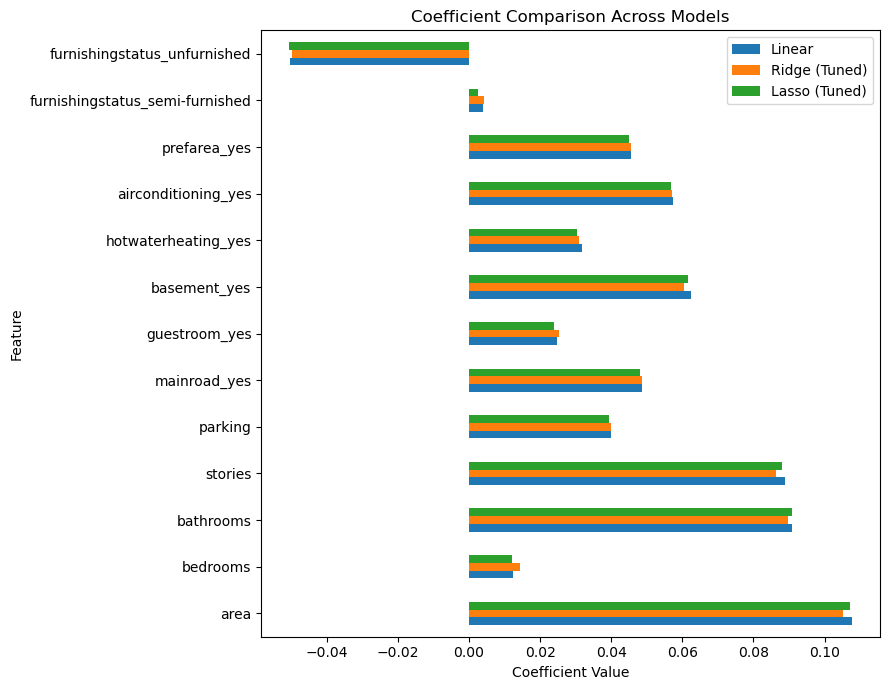

In [479]:
coef_comparison = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Linear': lr_model.coef_,
    'Ridge (Tuned)': ridge_tuned.coef_,
    'Lasso (Tuned)': lasso_tuned.coef_,
}).set_index('Feature')

coef_comparison.plot(kind='barh', figsize=(9, 7))
plt.title('Coefficient Comparison Across Models')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

Ridge has pulled every coefficient in very slightly towards zero, and Lasso has done the same, without dropping any feature completely at this particular alpha. The overall shape of the relationships (which features matter most) stays consistent across all three models, `area`, `bathrooms`, and `stories` are still the strongest positive drivers of price.

### <font color="blue"> Regularization Path

The clearest way to see what Ridge and Lasso are actually doing is to watch the coefficients change as `alpha` increases from very small to very large.

In [482]:
path_alphas = np.logspace(-4, 1, 60)

ridge_coef_path = []
lasso_coef_path = []
for a in path_alphas:
    ridge_coef_path.append(Ridge(alpha=a).fit(X_train_scaled, y_train).coef_)
    lasso_coef_path.append(Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train).coef_)

ridge_coef_path = np.array(ridge_coef_path)
lasso_coef_path = np.array(lasso_coef_path)

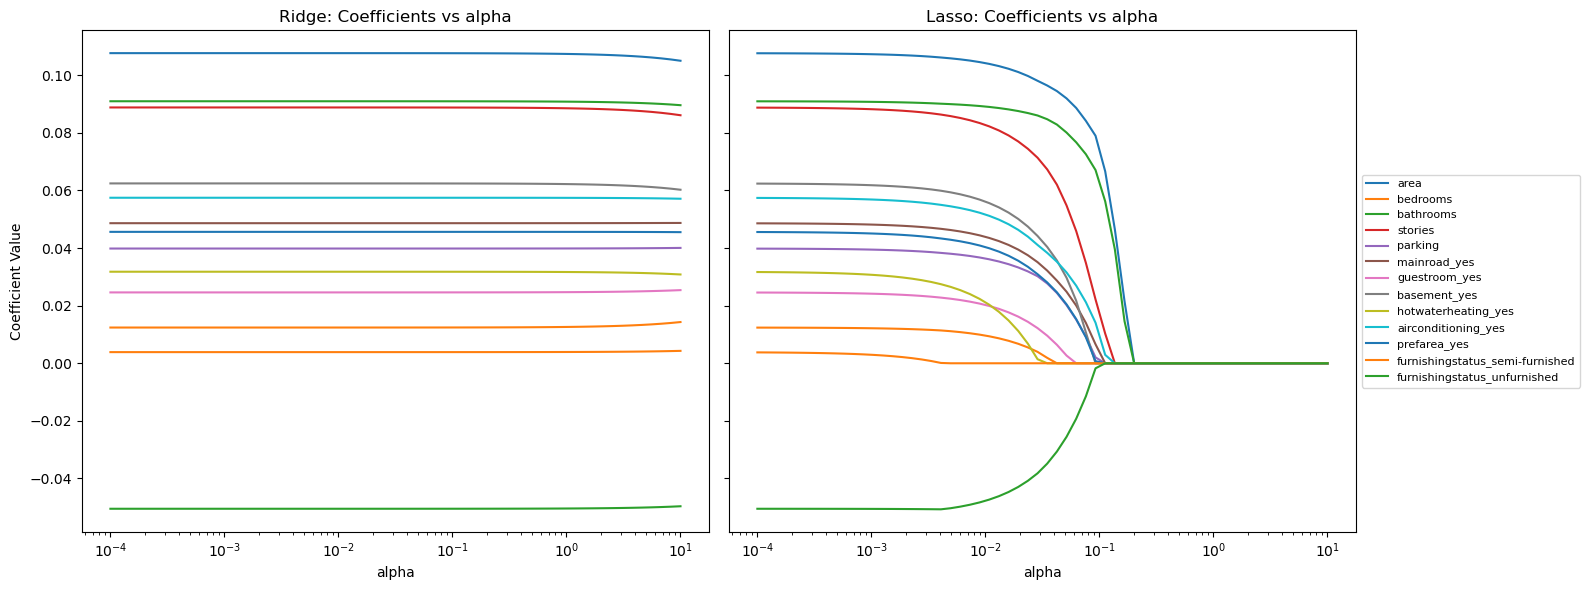

In [483]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, feature in enumerate(X_train_scaled.columns):
    axes[0].plot(path_alphas, ridge_coef_path[:, i], label=feature)
    axes[1].plot(path_alphas, lasso_coef_path[:, i], label=feature)

axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[0].set_title('Ridge: Coefficients vs alpha')
axes[1].set_title('Lasso: Coefficients vs alpha')
axes[0].set_xlabel('alpha')
axes[1].set_xlabel('alpha')
axes[0].set_ylabel('Coefficient Value')
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

This is the clearest illustration of the difference between the two:

* **Ridge (left)**: every coefficient shrinks smoothly and continuously as alpha increases, but none of them ever actually reach zero, even at large alpha.
* **Lasso (right)**: coefficients also shrink, but they hit exactly zero one at a time as alpha increases, the weakest features (like `furnishingstatus_semi-furnished`) drop out first, and by around alpha ≈ 0.26 every single coefficient has been zeroed out. That's exactly why our default Lasso model at alpha = 1.0 collapsed completely, it's well past the point where every feature has already been eliminated.

This is Lasso performing automatic feature selection, something Ridge simply cannot do.

## <font color="brown"> Conclusion

* The baseline Linear Regression model wasn't badly overfitting on this dataset to begin with, so the performance gains from regularization here are modest, a small improvement from tuned Ridge, and tuned Lasso matching the baseline.
* **Tuning alpha matters a lot more than the choice between Ridge and Lasso.** Leaving Ridge at its default barely changed anything, while leaving Lasso at its default destroyed the model entirely. Always tune `alpha` with cross-validation (e.g. `GridSearchCV`) rather than relying on the default.
* **Ridge** is a good default choice when features are correlated and you want to keep all of them but reduce their individual influence.
* **Lasso** is the better choice when you also want automatic feature selection, dropping features that don't add much, though on this dataset the optimal alpha for prediction accuracy didn't need to drop any.
* For deployment, the **tuned Ridge model** is the strongest performer here, but the **tuned Lasso model** is a very close second and would be preferable if a simpler, more selective feature set were the priority.